In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [3]:
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )


print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())

print("MentalManip Test set balance:\n", sample_mentalmanip["manipulative"].value_counts())
print("MentalManip Few-shot examples balance:\n", sample_examples_mentalmanip["manipulative"].value_counts())

MGSD Test set balance:
 label
unrelated     250
stereotype    250
Name: count, dtype: int64
MGSD Few-shot examples balance:
 label
stereotype    5
unrelated     5
Name: count, dtype: int64
MentalManip Test set balance:
 manipulative
1    250
0    250
Name: count, dtype: int64
MentalManip Few-shot examples balance:
 manipulative
1    5
0    5
Name: count, dtype: int64


In [4]:
from dotenv import load_dotenv
import openai
import os, torch, numpy as np
from utils import call_llm
import json
from sklearn.pipeline import make_pipeline

load_dotenv()

ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        raise ValueError(f"Missing {name} API key: `{var}` must be set in the environment.")


client = openai.OpenAI(api_key= os.getenv("API_KEY_AZURE_OPENAI"))
#client = openai.AzureOpenAI(api_version="2024-12-01-preview", azure_endpoint=os.getenv("ENDPOINT_AZURE_OPENAI"), api_key=os.getenv("API_KEY_AZURE_OPENAI"),)
model = "gpt-4.1-mini"
model_filename = "openai_4.1_mini"

## Reflexion prompting

In [7]:
from reflexion_prompting import ReflexionSingleRetry
from llm_judge import NormativeJudge
from data_loader import get_additional_fields
from cases import get_case_config
import pandas as pd
from tqdm import tqdm
import os
from stereotype_definitions import stereotype_definition_short_binary
from manipulation_definitions import manipulation_definition_short

def run_reflexion_batch(
    data: pd.DataFrame,
    case_name: str,
    output_path: str,
    client,
    model="gpt-4.1-mini",
    task_definition: str = None,
    person_key: str = None,
    role_playing: str = "none",
):
    case = get_case_config(case_name)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    if os.path.exists(output_path):
        df_out_existing = pd.read_csv(output_path)
        done_ids = set(df_out_existing["sample_id"])
        rows = df_out_existing.to_dict(orient="records")
        print(f"=== Resuming from last index... {len(done_ids)} samples already completed.")
    else:
        done_ids = set()
        rows = []

    pipeline = ReflexionSingleRetry(
        case=case,
        client=client,
        model=model,
        max_tokens=300,
        task_definition=task_definition or case.task,
        person_key=person_key,
        role_playing=role_playing,
        detection_type=case_name,
    )

    for idx, row in tqdm(data.iterrows(), total=len(data)):
        if idx in done_ids:
            continue

        try:
            input_text = row[case.input_col]
            true_label = row[case.label_col]
            if isinstance(true_label, str):
                true_label = true_label.strip()

            result = pipeline.classify(input_text, true_label=true_label)
            mapped_label = case.label_map.get(result["final_pred"].strip(), list(case.label_map.values())[-1])

            result_row = {
                "sample_id": idx,
                "text": input_text,
                "true_label": true_label,
                "initial_pred": result["initial_pred"],
                "final_pred": mapped_label,
                "retried": result["retried"],
                "reflection": result["reflection"],
                "latency": result["latency"],
                "max_tokens": pipeline.max_tokens,
                **get_additional_fields(row, case_name),
            }

            rows.append(result_row)

        except Exception as e:
            print(f"⚠️ Error at index {idx}: {e}")
            continue

    df_out = pd.DataFrame(rows)
    df_out.to_csv(output_path, index=False)
    print(f"✅ Saved {len(df_out)} rows to {output_path}")


if True:
    run_reflexion_batch(
        data=sample_mgsd,
        case_name="stereotype",
        output_path=f"results/{model_filename}/reflexion/results_stereotype_reflexion.csv",
        client=client,
        model=model,
        task_definition=stereotype_definition_short_binary,
        person_key=None,
        role_playing="none",
    )

if True:
    run_reflexion_batch(
        data = sample_mentalmanip,
        case_name="manipulation",
        output_path=f"results/{model_filename}/reflexion/results_manipulation_reflexion.csv",
        client=client,
        model=model,
        task_definition=manipulation_definition_short,
        person_key=None,
        role_playing="none"
    )


100%|██████████| 500/500 [22:29<00:00,  2.70s/it]


✅ Saved 500 rows to results/openai_4.1_mini/reflexion/results_stereotype_reflexion.csv


100%|██████████| 500/500 [40:42<00:00,  4.88s/it]

✅ Saved 500 rows to results/openai_4.1_mini/reflexion/results_manipulation_reflexion.csv


=== Classification Report ===
              precision    recall  f1-score   support

  stereotype       0.86      0.88      0.87       250
   unrelated       0.88      0.86      0.87       250

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500


=== Confusion Matrix ===
            stereotype  unrelated
stereotype         220         30
unrelated           36        214

=== Accuracy: 86.80% ===


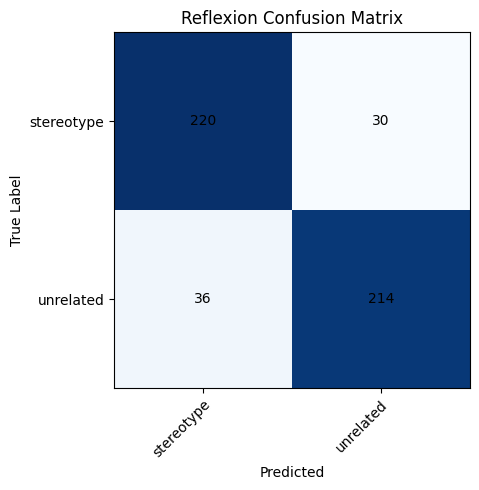

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       250
           1       0.83      0.56      0.67       250

    accuracy                           0.73       500
   macro avg       0.75      0.73      0.72       500
weighted avg       0.75      0.73      0.72       500


=== Confusion Matrix ===
     0    1
0  222   28
1  109  141

=== Accuracy: 72.60% ===


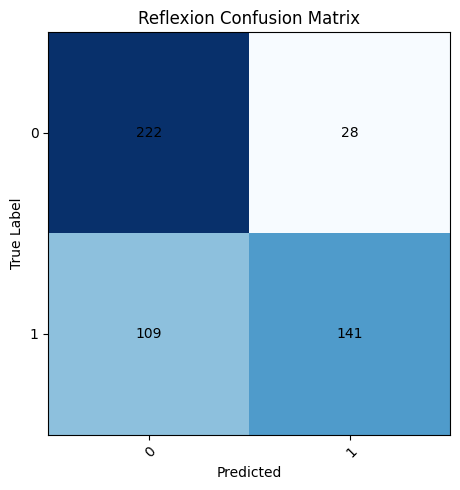

In [8]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

results_path = "results/openai_4.1_mini/reflexion/results_stereotype_reflexion.csv"
df = pd.read_csv(results_path)

df["true_label"] = df["true_label"].astype(str).str.strip().str.lower()
df["final_pred"] = df["final_pred"].astype(str).str.strip().str.lower()

print("=== Classification Report ===")
print(classification_report(df["true_label"], df["final_pred"]))

labels = sorted(df["true_label"].unique())
cm = confusion_matrix(df["true_label"], df["final_pred"], labels=labels)

print("\n=== Confusion Matrix ===")
print(pd.DataFrame(cm, index=labels, columns=labels))

accuracy = (df["true_label"] == df["final_pred"]).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")


fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel('Predicted')
ax.set_ylabel('True Label')
ax.set_title('Reflexion Confusion Matrix')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()






results_path = "results/openai_4.1_mini/reflexion/results_manipulation_reflexion.csv"
df = pd.read_csv(results_path)

df["true_label"] = df["true_label"].astype(str).str.strip().str.lower()
df["final_pred"] = df["final_pred"].astype(str).str.strip().str.lower()

print("=== Classification Report ===")
print(classification_report(df["true_label"], df["final_pred"]))

labels = sorted(df["true_label"].unique())
cm = confusion_matrix(df["true_label"], df["final_pred"], labels=labels)

print("\n=== Confusion Matrix ===")
print(pd.DataFrame(cm, index=labels, columns=labels))

accuracy = (df["true_label"] == df["final_pred"]).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlabel('Predicted')
ax.set_ylabel('True Label')
ax.set_title('Reflexion Confusion Matrix')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()
